## Installation

Install Ammonyte using pip:

```bash
pip install ammonyte
```

## Importing the Package

The standard convention is to import Ammonyte as `amt`:

In [1]:
import ammonyte as amt

## Loading a Time Series

The central object in Ammonyte is `ammonyte.Series`. It extends `pyleoclim.Series` and serves as the starting point for all analyses.

Use the `Series.from_csv()` method to load a time series from a CSV file. Throughout the Ammonyte tutorials we use the **NGRIP (North Greenland Ice Core Project)** dataset, which contains high-resolution $\delta^{18}O$ isotope measurements spanning the last glacial period. This dataset is well-suited for studying abrupt climate transitions such as Dansgaard-Oeschger events.

**Key dataset features:**
- **Proxy variable**: $\delta^{18}O$ isotope measurements
- **Units**: per mil (‰)
- **Time scale**: Thousands of years before present (kyr b2k)

In [2]:
ngrip = amt.Series.from_csv('../ammonyte/data/NGRIP.csv')
ngrip

Time axis values sorted in ascending order
Time axis values sorted in ascending order
{'label': 'NGRIP Ice Core Data'}


None
Age [kyr b2k]
0.05     -35.11
0.07     -34.65
0.09     -34.53
0.11     -35.29
0.13     -35.02
          ...  
122.19   -32.85
122.21   -32.66
122.23   -32.66
122.25   -32.51
122.27   -32.56
Name: δ¹⁸O [‰], Length: 6112, dtype: float64

## Exploring the Series

Once loaded, you can inspect the key metadata attributes of the series:

In [3]:
print(f"Label:      {ngrip.label}")
print(f"Value name: {ngrip.value_name}")
print(f"Value unit: {ngrip.value_unit}")
print(f"Time name:  {ngrip.time_name}")
print(f"Time unit:  {ngrip.time_unit}")
print(f"Time range: {ngrip.time.min():.2f} – {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Data points: {len(ngrip.time)}")

Label:      NGRIP Ice Core Data
Value name: δ¹⁸O
Value unit: ‰
Time name:  Age
Time unit:  kyr b2k
Time range: 0.05 – 122.27 kyr b2k
Data points: 6112


## Visualizing the Series

Since `ammonyte.Series` inherits from `pyleoclim.Series`, you can use the `.plot()` method directly to visualize the time series:

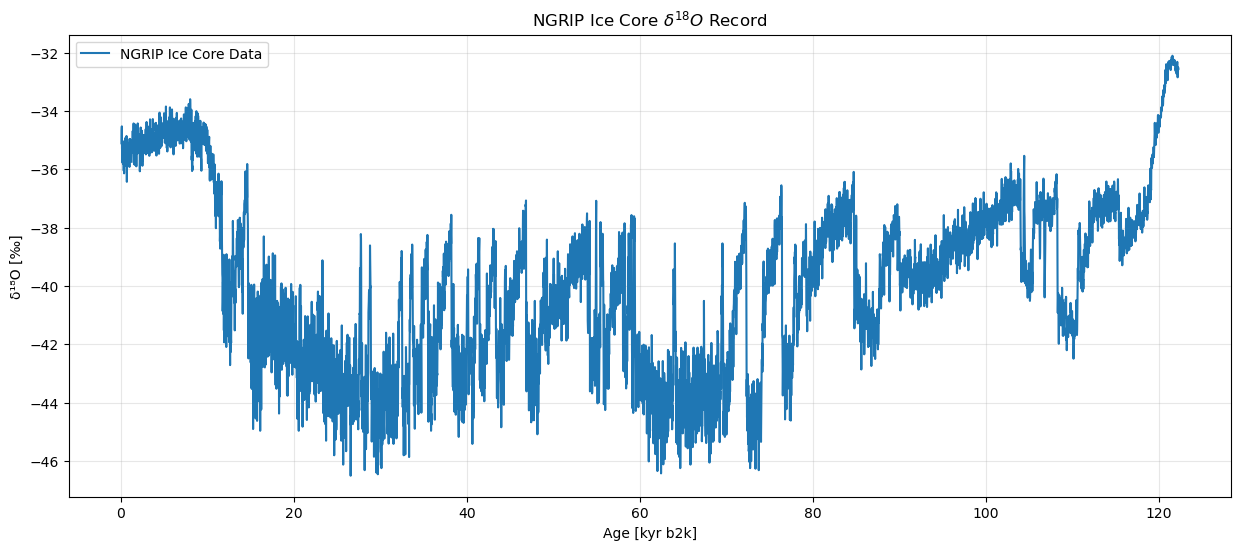

In [4]:
fig, ax = ngrip.plot(figsize=(15, 6))
ax.set_title('NGRIP Ice Core $\delta^{18}O$ Record')
ax.grid(True, alpha=0.3)

## GeoSeries — Adding Geographic Context

`ammonyte.GeoSeries` extends `Series` by attaching location metadata to a geographically referenced archive. It inherits all of Ammonyte's transition detection methods plus the geospatial methods from `pyleoclim.GeoSeries`, such as `.map()`.

Since the NGRIP ice core was drilled at a known location in Greenland, we can wrap the series we already loaded into a `GeoSeries` by adding:

- **`lat`** / **`lon`** — drill site coordinates
- **`elevation`** — metres above sea level
- **`archiveType`** — type of climate archive (styles the map marker)

In [5]:
ngrip_geo = amt.GeoSeries(
    time=ngrip.time,
    value=ngrip.value,
    lat=75.1,
    lon=-42.32,
    elevation=3090,
    time_name=ngrip.time_name,
    time_unit=ngrip.time_unit,
    value_name=ngrip.value_name,
    value_unit=ngrip.value_unit,
    label=ngrip.label,
    archiveType='GlacierIce'
)
ngrip_geo

Time axis values sorted in ascending order
{'archiveType': 'GlacierIce', 'label': 'NGRIP Ice Core Data'}


None
Age [kyr b2k]
0.05     -35.11
0.07     -34.65
0.09     -34.53
0.11     -35.29
0.13     -35.02
          ...  
122.19   -32.85
122.21   -32.66
122.23   -32.66
122.25   -32.51
122.27   -32.56
Name: δ¹⁸O [‰], Length: 6112, dtype: float64

The `.map()` method places the archive on a world map, using the `archiveType` to style the marker:

(<Figure size 1800x700 with 1 Axes>,
 {'map': <GeoAxes: xlabel='lon', ylabel='lat'>})

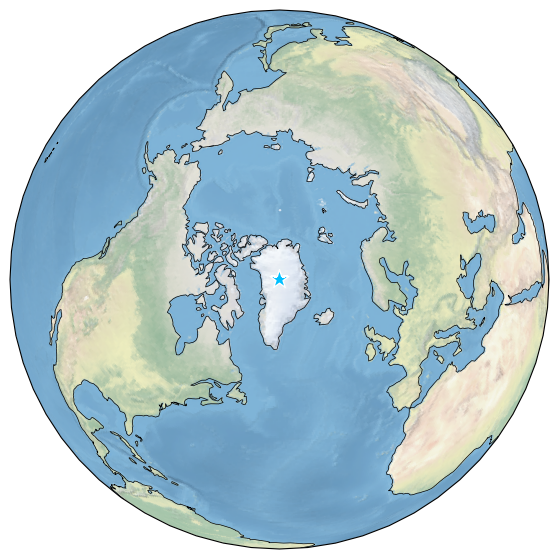

In [6]:
ngrip_geo.map()